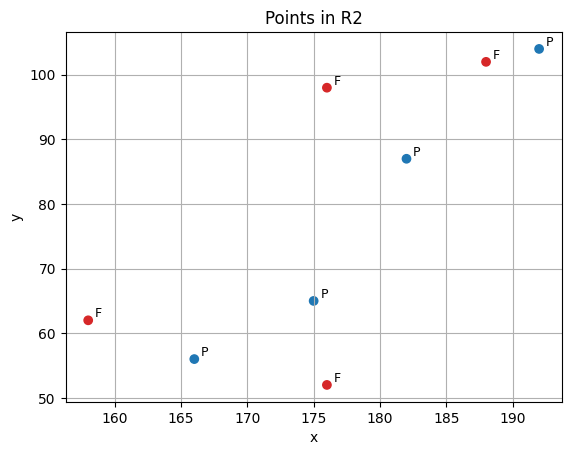

Minimum number of nodes for perfect classification: 9
[{'leaf': False, 'feature': 0, 'threshold': 162.0, 'left': {'leaf': True, 'value': 'F'}, 'right': {'leaf': False, 'feature': 0, 'threshold': 190.0, 'left': {'leaf': False, 'feature': 1, 'threshold': 54.0, 'left': {'leaf': True, 'value': 'F'}, 'right': {'leaf': False, 'feature': 1, 'threshold': 92.5, 'left': {'leaf': True, 'value': 'P'}, 'right': {'leaf': True, 'value': 'F'}}}, 'right': {'leaf': True, 'value': 'P'}}}, {'leaf': False, 'feature': 0, 'threshold': 162.0, 'left': {'leaf': True, 'value': 'F'}, 'right': {'leaf': False, 'feature': 0, 'threshold': 190.0, 'left': {'leaf': False, 'feature': 1, 'threshold': 92.5, 'left': {'leaf': False, 'feature': 1, 'threshold': 54.0, 'left': {'leaf': True, 'value': 'F'}, 'right': {'leaf': True, 'value': 'P'}}, 'right': {'leaf': True, 'value': 'F'}}, 'right': {'leaf': True, 'value': 'P'}}}, {'leaf': False, 'feature': 0, 'threshold': 162.0, 'left': {'leaf': True, 'value': 'F'}, 'right': {'leaf':

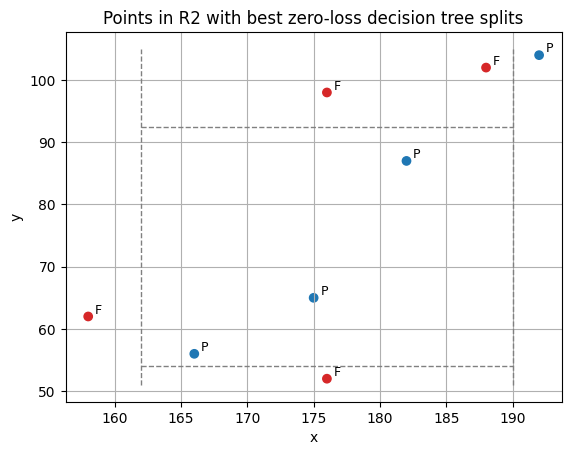

In [3]:
import matplotlib.pyplot as plt

points = [
    (175, 65, "P"), (158, 62, "F"), (188, 102, "F"), (176, 98, "F"),
    (182, 87, "P"), (176, 52, "F"), (166, 56, "P"), (192, 104, "P")
]

xs = [p[0] for p in points]
ys = [p[1] for p in points]
labels = [p[2] for p in points]
colors = ["tab:blue" if l == "P" else "tab:red" for l in labels]

plt.figure()
plt.scatter(xs, ys, c=colors)
for x, y, l in points:
    plt.text(x + 0.5, y + 0.5, l, fontsize=9)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Points in R2")
plt.grid(True)
plt.show()


# Build all axis-aligned decision trees that classify the points perfectly,
# then pick the one with the least number of nodes.

def subset_key(indices):
    return frozenset(indices)

def all_thresholds(values):
    vals = sorted(set(values))
    return [ (vals[i] + vals[i+1]) / 2 for i in range(len(vals) - 1) ]

memo = {}  # subset -> (min_nodes, [tree_structs])

def build_all_best_trees(indices):
    key = subset_key(indices)
    if key in memo:
        return memo[key]

    labels_subset = [labels[i] for i in indices]
    if len(set(labels_subset)) == 1:
        leaf = {"leaf": True, "value": labels_subset[0]}
        memo[key] = (1, [leaf])
        return memo[key]

    best_nodes = float("inf")
    best_trees = []


    for feature in (0, 1):  # 0 -> x, 1 -> y
        feature_values = [points[i][feature] for i in indices]
        for thr in all_thresholds(feature_values):
            left_inds = [i for i in indices if points[i][feature] <= thr]
            right_inds = [i for i in indices if points[i][feature] > thr]
            if not left_inds or not right_inds:
                continue

            left_nodes, left_trees = build_all_best_trees(left_inds)
            right_nodes, right_trees = build_all_best_trees(right_inds)

            total_nodes = 1 + left_nodes + right_nodes
            if total_nodes > best_nodes:
                continue

            for lt in left_trees:
                for rt in right_trees:
                    tree = {
                        "leaf": False,
                        "feature": feature,
                        "threshold": thr,
                        "left": lt,
                        "right": rt,
                    }
                    if total_nodes < best_nodes:
                        best_nodes = total_nodes
                        best_trees = [tree]
                    else:
                        best_trees.append(tree)

    if not best_trees:
        memo[key] = (float("inf"), [])
    else:
        memo[key] = (best_nodes, best_trees)
    return memo[key]

all_indices = list(range(len(points)))
min_nodes, best_trees = build_all_best_trees(all_indices)

print(f"Minimum number of nodes for perfect classification: {min_nodes}")
print(best_trees)
best_tree = best_trees[0]

def print_tree(tree, depth=0):
    indent = "    " * depth
    if tree["leaf"]:
        print(f"{indent}Leaf -> {tree['value']}")
    else:
        feat = "x" if tree["feature"] == 0 else "y"
        thr = tree["threshold"]
        print(f"{indent}if {feat} <= {thr:.3f}:")
        print_tree(tree["left"], depth + 1)
        print(f"{indent}else:")
        print_tree(tree["right"], depth + 1)

print_tree(best_tree)

def plot_tree_splits(tree, x_min, x_max, y_min, y_max):
    if tree["leaf"]:
        return
    if tree["feature"] == 0:
        thr = tree["threshold"]
        plt.plot([thr, thr], [y_min, y_max], color="gray", linestyle="--", linewidth=1)
        plot_tree_splits(tree["left"], x_min, thr, y_min, y_max)
        plot_tree_splits(tree["right"], thr, x_max, y_min, y_max)
    else:
        thr = tree["threshold"]
        plt.plot([x_min, x_max], [thr, thr], color="gray", linestyle="--", linewidth=1)
        plot_tree_splits(tree["left"], x_min, x_max, y_min, thr)
        plot_tree_splits(tree["right"], x_min, x_max, thr, y_max)

x_min, x_max = min(xs) - 1, max(xs) + 1
y_min, y_max = min(ys) - 1, max(ys) + 1

plt.figure()
plt.scatter(xs, ys, c=colors)
for x, y, l in points:
    plt.text(x + 0.5, y + 0.5, l, fontsize=9)
plot_tree_splits(best_tree, x_min, x_max, y_min, y_max)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Points in R2 with best zero-loss decision tree splits")
plt.grid(True)
plt.show()